In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 




In [5]:
df = pd.read_csv('heart.csv')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [6]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
df.shape

(918, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: >

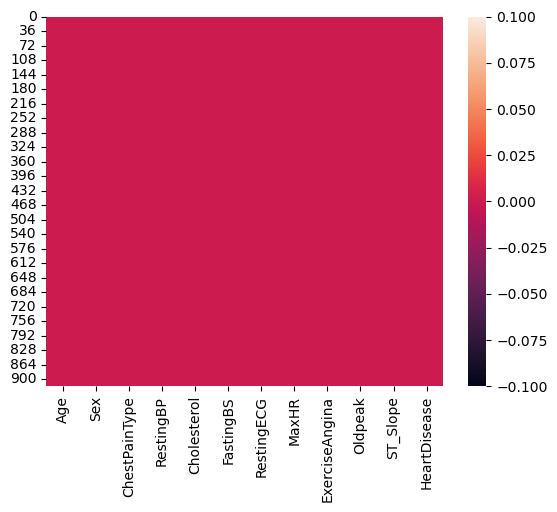

In [14]:
sns.heatmap(df.isnull())

In [15]:
df.duplicated().sum()

0

In [18]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

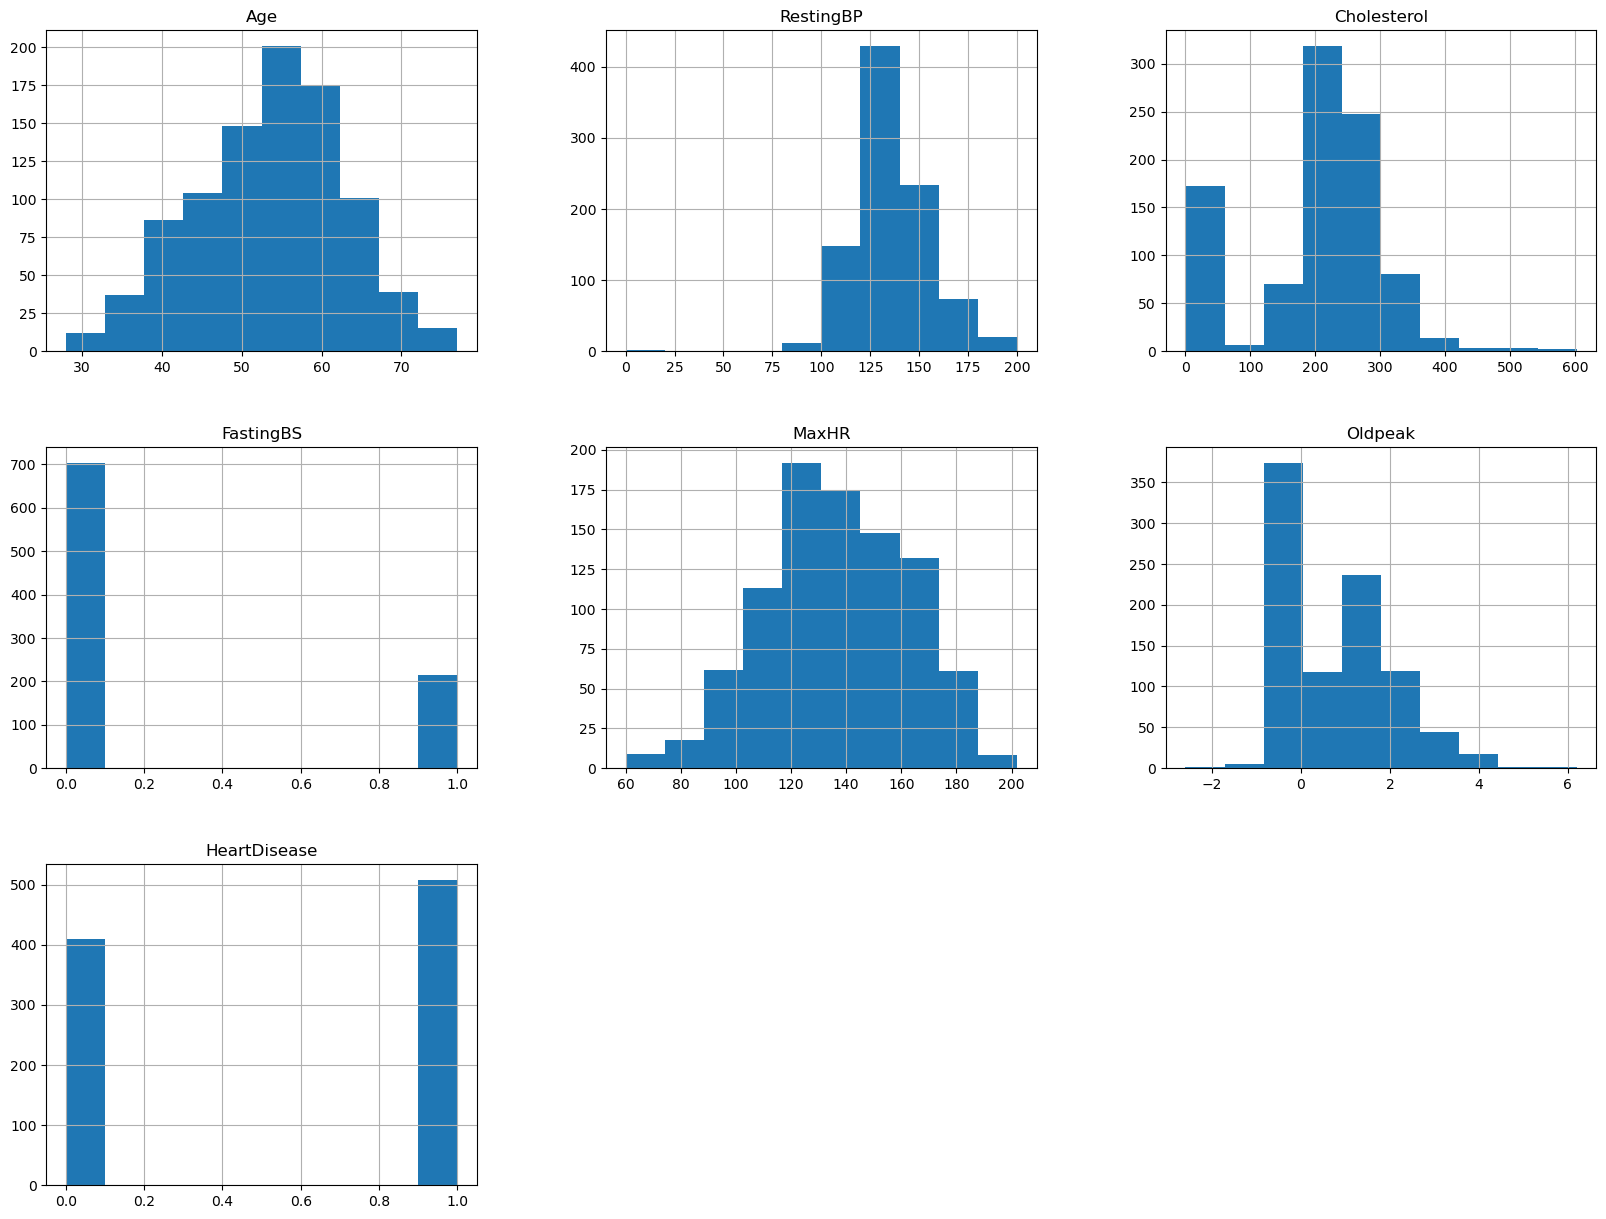

In [21]:
df.hist(figsize=(20,15))
plt.show()

In [24]:
cor = df.corr(numeric_only = True)

<Axes: >

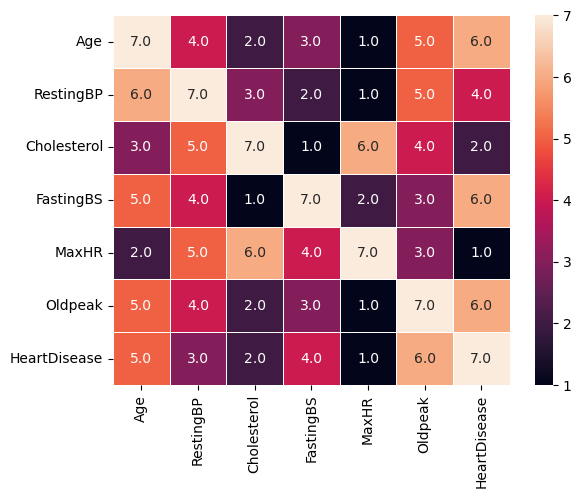

In [29]:
sns.heatmap(cor.rank(axis='columns') , annot=True , fmt='.1f' , linewidth=.5)

In [30]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()

In [34]:
obj = df.select_dtypes(include='object')
non_obj = df.select_dtypes(exclude='object')

In [37]:
for i in range(0,obj.shape[1]):
    obj.iloc[:,i] = lab.fit_transform(obj.iloc[:,1])

In [39]:
data = pd.concat([obj,non_obj], axis=1)
data

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,1,1,1,1,1,40,140,289,0,172,0.0,0
1,2,2,2,2,2,49,160,180,0,156,1.0,1
2,1,1,1,1,1,37,130,283,0,98,0.0,0
3,0,0,0,0,0,48,138,214,0,108,1.5,1
4,2,2,2,2,2,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,3,3,3,3,3,45,110,264,0,132,1.2,1
914,0,0,0,0,0,68,144,193,1,141,3.4,1
915,0,0,0,0,0,57,130,131,0,115,1.2,1
916,1,1,1,1,1,57,130,236,0,174,0.0,1


Machine learing Model

In [47]:
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [48]:
x = data.drop(['HeartDisease'] , axis=1)
y = data['HeartDisease']


In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=.8)

In [52]:
def all(model) :
    model.fit(x_train , y_train)
    pre = model.predict(x_test)
    print(confusion_matrix(pre , y_test))
    print(classification_report(pre , y_test))

In [53]:
model1 = KNeighborsClassifier()
all(model1)

[[50 26]
 [32 76]]
              precision    recall  f1-score   support

           0       0.61      0.66      0.63        76
           1       0.75      0.70      0.72       108

    accuracy                           0.68       184
   macro avg       0.68      0.68      0.68       184
weighted avg       0.69      0.68      0.69       184



In [54]:
model2=DecisionTreeClassifier()
all(model2)

[[61 26]
 [21 76]]
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        87
           1       0.75      0.78      0.76        97

    accuracy                           0.74       184
   macro avg       0.74      0.74      0.74       184
weighted avg       0.74      0.74      0.74       184



In [55]:
model3=GaussianNB()
all(model3)

[[56 22]
 [26 80]]
              precision    recall  f1-score   support

           0       0.68      0.72      0.70        78
           1       0.78      0.75      0.77       106

    accuracy                           0.74       184
   macro avg       0.73      0.74      0.73       184
weighted avg       0.74      0.74      0.74       184



In [56]:
model4=SVC()
all(model4)

[[52 31]
 [30 71]]
              precision    recall  f1-score   support

           0       0.63      0.63      0.63        83
           1       0.70      0.70      0.70       101

    accuracy                           0.67       184
   macro avg       0.67      0.66      0.66       184
weighted avg       0.67      0.67      0.67       184



In [57]:
model5=RandomForestClassifier()
all(model5)

[[61 19]
 [21 83]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        80
           1       0.81      0.80      0.81       104

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



In [58]:
model6=GradientBoostingClassifier()
all(model6)

[[62 21]
 [20 81]]
              precision    recall  f1-score   support

           0       0.76      0.75      0.75        83
           1       0.79      0.80      0.80       101

    accuracy                           0.78       184
   macro avg       0.78      0.77      0.77       184
weighted avg       0.78      0.78      0.78       184

